# STOCK PRICE FORECASTING : A MACHINE LEARNING AND DEEP LEARNING APPROACH

## INTRODUCTION

The stock market is an important financial system where shares of companies are bought and sold.
Stock prices fluctuate due to factors such as company performance, market trends, and economic conditions.
Machine Learning (ML) and Deep Learning (DL) techniques are used to analyze historical stock data and identify patterns.
These predictions help investors make informed decisions about future price movements.
This is useful for better investment planning, risk management, and maximizing returns.

In this project, we analyze and predict stock prices of:

#### Apple Inc.

#### Tesla, Inc.

#### Amazon.com, Inc.

#### Alphabet Inc.

### OBJECTIVES OF THE PROJECT
To analyze historical stock data

To identify trends and patterns

To build prediction models

To forecast future stock prices

## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

## DATA COLLECTION
We collect historical stock price data using Yahoo Finance through the yfinance library.

In [2]:
stocks = ['AAPL', 'TSLA', 'AMZN', 'GOOGL']

data = yf.download(stocks, start='2018-01-01', end='2024-12-31')

close_prices = data['Close']

close_prices.head()

[*********************100%***********************]  4 of 4 completed


Ticker,AAPL,AMZN,GOOGL,TSLA
Date,,,,
2018-01-02,40.304165,59.450500,53.220631,21.368668
2018-01-03,40.297146,60.209999,54.128624,21.150000
2018-01-04,40.484329,60.479500,54.338890,20.974667
2018-01-05,40.945263,61.457001,55.059429,21.105333
2018-01-08,40.793190,62.343498,55.253822,22.427334


## BASIC DATA INFORMATION

In [3]:
data.info()
data.describe()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1760 entries, 2018-01-02 to 2024-12-30
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    1760 non-null   float64
 1   (Close, AMZN)    1760 non-null   float64
 2   (Close, GOOGL)   1760 non-null   float64
 3   (Close, TSLA)    1760 non-null   float64
 4   (High, AAPL)     1760 non-null   float64
 5   (High, AMZN)     1760 non-null   float64
 6   (High, GOOGL)    1760 non-null   float64
 7   (High, TSLA)     1760 non-null   float64
 8   (Low, AAPL)      1760 non-null   float64
 9   (Low, AMZN)      1760 non-null   float64
 10  (Low, GOOGL)     1760 non-null   float64
 11  (Low, TSLA)      1760 non-null   float64
 12  (Open, AAPL)     1760 non-null   float64
 13  (Open, AMZN)     1760 non-null   float64
 14  (Open, GOOGL)    1760 non-null   float64
 15  (Open, TSLA)     1760 non-null   float64
 16  (Volume, AAPL)   1760 non-null   int64  
 

Price   Ticker
Close   AAPL      0
        AMZN      0
        GOOGL     0
        TSLA      0
High    AAPL      0
        AMZN      0
        GOOGL     0
        TSLA      0
Low     AAPL      0
        AMZN      0
        GOOGL     0
        TSLA      0
Open    AAPL      0
        AMZN      0
        GOOGL     0
        TSLA      0
Volume  AAPL      0
        AMZN      0
        GOOGL     0
        TSLA      0
dtype: int64

#### STATISTICAL SUMMARY

In [4]:
data.describe()

Price         Close                                                High  \
Ticker         AAPL         AMZN        GOOGL         TSLA         AAPL   
count   1760.000000  1760.000000  1760.000000  1760.000000  1760.000000   
mean     121.664109   129.257973   100.728799   157.952966   122.870583   
std       59.001786    38.822726    38.709394   112.312011    59.469787   
min       33.768089    59.450500    48.829922    11.931333    34.606413   
25%       54.026799    92.620123    61.207373    23.173834    54.727259   
50%      131.293930   127.125000    99.150528   182.964996   132.726038   
75%      168.494446   163.413628   133.782677   242.913330   170.040503   
max      257.612732   232.929993   195.754990   479.859985   258.686881   

Price                                                  Low               \
Ticker         AMZN        GOOGL         TSLA         AAPL         AMZN   
count   1760.000000  1760.000000  1760.000000  1760.000000  1760.000000   
mean     130.806071   101.802645   161.508081   120.319642   127.641631   
std       39.194317    39.087611   114.900689    58.439003    38.469103   
min       59.500000    50.191169    12.445333    33.722966    58.525501   
25%       93.701998    61.743323    23.511667    53.651972    91.527498   
50%      129.035004   100.271260   186.415001   129.931641   125.350002   
75%      165.258499   135.130022   248.184166   167.042208   161.538872   
max      233.000000   200.493095   488.540009   256.230300   228.009995   

Price                                    Open                            \
Ticker        GOOGL         TSLA         AAPL         AMZN        GOOGL   
count   1760.000000  1760.000000  1760.000000  1760.000000  1760.000000   
mean      99.609309   154.217363   121.541275   129.288194   100.673747   
std       38.340103   109.635012    58.927398    38.850876    38.704588   
min       48.482293    11.799333    34.193187    58.599998    48.812563   
25%       60.701924    22.814500    54.219617    92.630875    61.289073   
50%       97.365285   179.004997   131.642292   127.369999    98.714127   
75%      132.226783   238.162495   168.270626   163.711128   133.652869   
max      194.082729   457.510010   256.787255   232.389999   196.342287   

Price                      Volume                                            
Ticker         TSLA          AAPL          AMZN         GOOGL          TSLA  
count   1760.000000  1.760000e+03  1.760000e+03  1.760000e+03  1.760000e+03  
mean     157.972523  1.001761e+08  7.612767e+07  3.380927e+07  1.277805e+08  
std      112.399517  5.520982e+07  3.975320e+07  1.530324e+07  7.961145e+07  
min       12.073333  2.323470e+07  1.500750e+07  9.312000e+06  2.940180e+07  
25%       23.158834  6.312485e+07  4.977648e+07  2.400310e+07  7.888222e+07  
50%      183.216667  8.674660e+07  6.531000e+07  3.009500e+07  1.048698e+08  
75%      243.230003  1.214590e+08  9.170450e+07  3.842050e+07  1.479257e+08  
max      475.899994  4.265100e+08  3.113460e+08  1.331780e+08  9.140820e+08

#### STOCK PRICE TREND VISUALIZATION

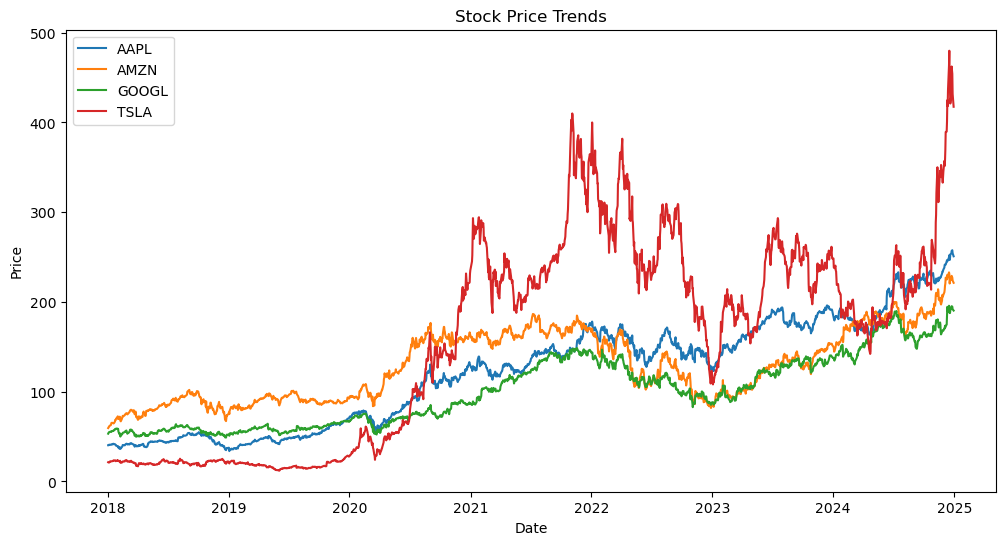

In [5]:
plt.figure(figsize=(12,6))

for stock in close_prices.columns:
    plt.plot(close_prices[stock],label=stock)

plt.title("Stock Price Trends")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## CORRELATION HEATMAP

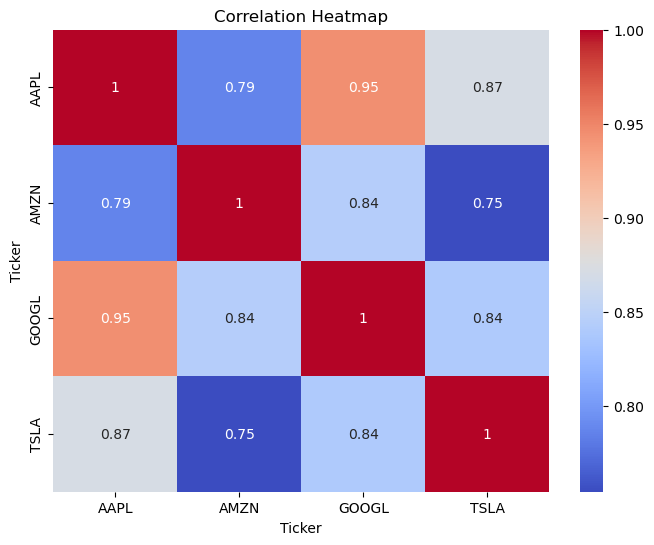

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(close_prices.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## NORMALIZED STOCK COMPARISON

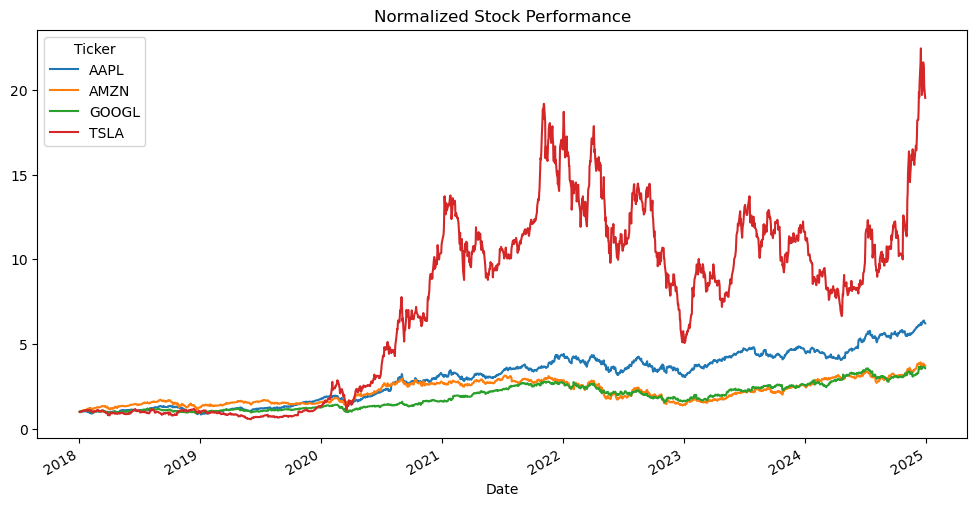

In [7]:
normalized = close_prices / close_prices.iloc[0]

normalized.plot(figsize=(12,6))

plt.title("Normalized Stock Performance")

plt.show()

## DISTRIBUTION OF DAILY STOCK RETURNS

[*********************100%***********************]  4 of 4 completed


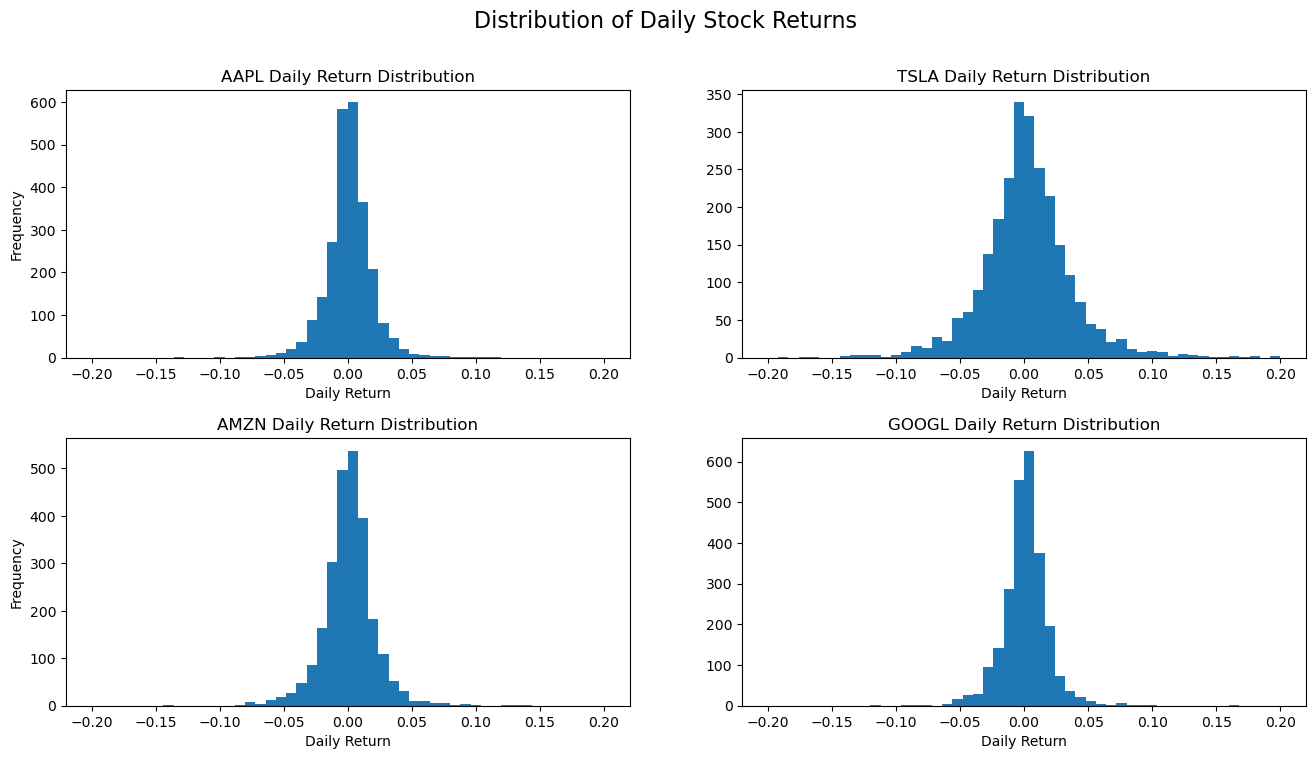

In [8]:
# Download stock data
data = yf.download(stocks, start="2015-01-01", end="2024-12-31")

# Extract closing prices
close_prices = data['Close']

# Calculate daily returns
returns = close_prices.pct_change().dropna()

# Create subplot layout
fig, axs = plt.subplots(2, 2, figsize=(16,8),
                        gridspec_kw={'hspace':0.3, 'wspace':0.2})

# AAPL
axs[0,0].hist(returns['AAPL'], bins=50, range=(-0.2,0.2))
axs[0,0].set_title("AAPL Daily Return Distribution")
axs[0,0].set_xlabel("Daily Return")
axs[0,0].set_ylabel("Frequency")

# TSLA
axs[0,1].hist(returns['TSLA'], bins=50, range=(-0.2,0.2))
axs[0,1].set_title("TSLA Daily Return Distribution")
axs[0,1].set_xlabel("Daily Return")

# AMZN
axs[1,0].hist(returns['AMZN'], bins=50, range=(-0.2,0.2))
axs[1,0].set_title("AMZN Daily Return Distribution")
axs[1,0].set_xlabel("Daily Return")
axs[1,0].set_ylabel("Frequency")

# GOOGL
axs[1,1].hist(returns['GOOGL'], bins=50, range=(-0.2,0.2))
axs[1,1].set_title("GOOGL Daily Return Distribution")
axs[1,1].set_xlabel("Daily Return")

# Overall title
fig.suptitle("Distribution of Daily Stock Returns", fontsize=16)

plt.show()

## STOCK PROCE TRENDS

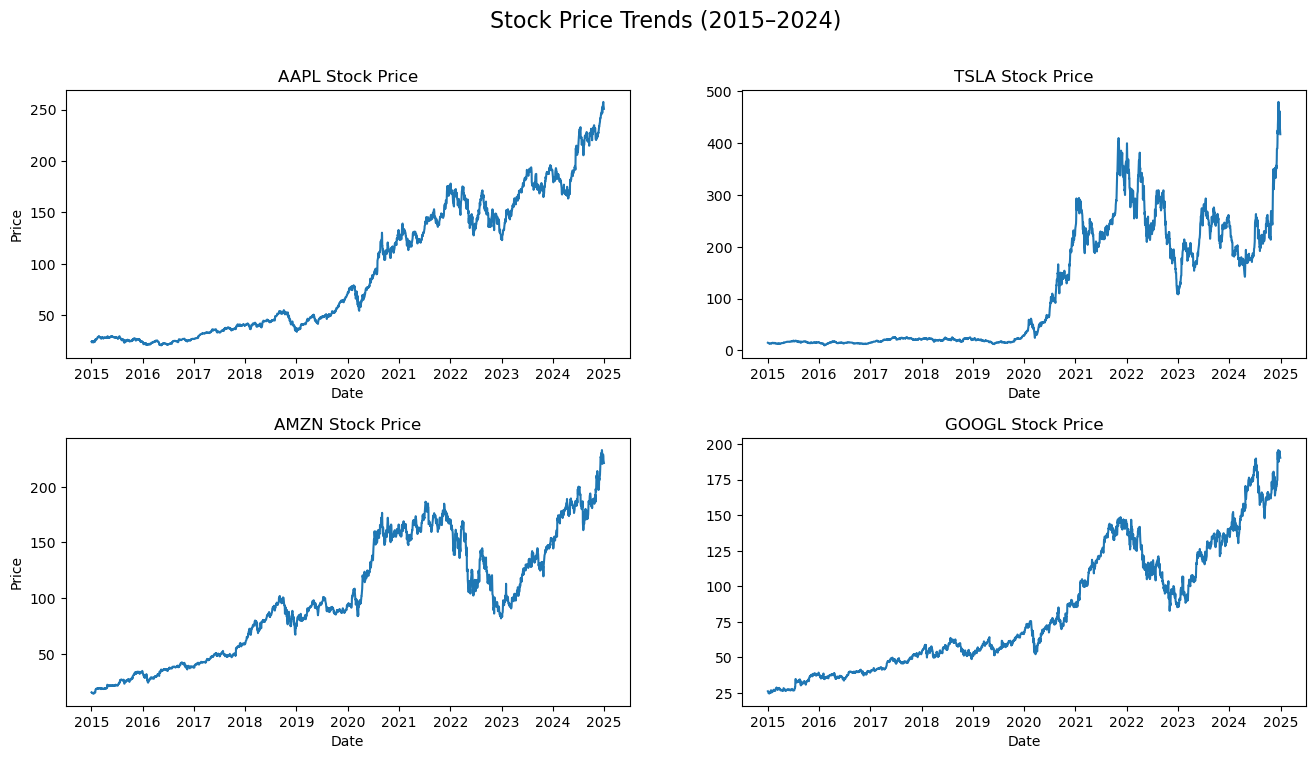

In [9]:
# Extract closing prices 
close_prices = data['Close']

# Calculate daily returns
returns = close_prices.pct_change().dropna()

# Create subplot layout
fig, axs = plt.subplots(2, 2, figsize=(16,8),
                        gridspec_kw={'hspace':0.3, 'wspace':0.2})

# Apple
axs[0,0].plot(close_prices['AAPL'])
axs[0,0].set_title("AAPL Stock Price")
axs[0,0].set_xlabel("Date")
axs[0,0].set_ylabel("Price")

# Tesla
axs[0,1].plot(close_prices['TSLA'])
axs[0,1].set_title("TSLA Stock Price")
axs[0,1].set_xlabel("Date")

# Amazon
axs[1,0].plot(close_prices['AMZN'])
axs[1,0].set_title("AMZN Stock Price")
axs[1,0].set_xlabel("Date")
axs[1,0].set_ylabel("Price")

# Alphabet (Google)
axs[1,1].plot(close_prices['GOOGL'])
axs[1,1].set_title("GOOGL Stock Price")
axs[1,1].set_xlabel("Date")

fig.suptitle("Stock Price Trends (2015–2024)", fontsize=16)

plt.show()

## DAILY RETURN VOLATALITY

[*********************100%***********************]  4 of 4 completed


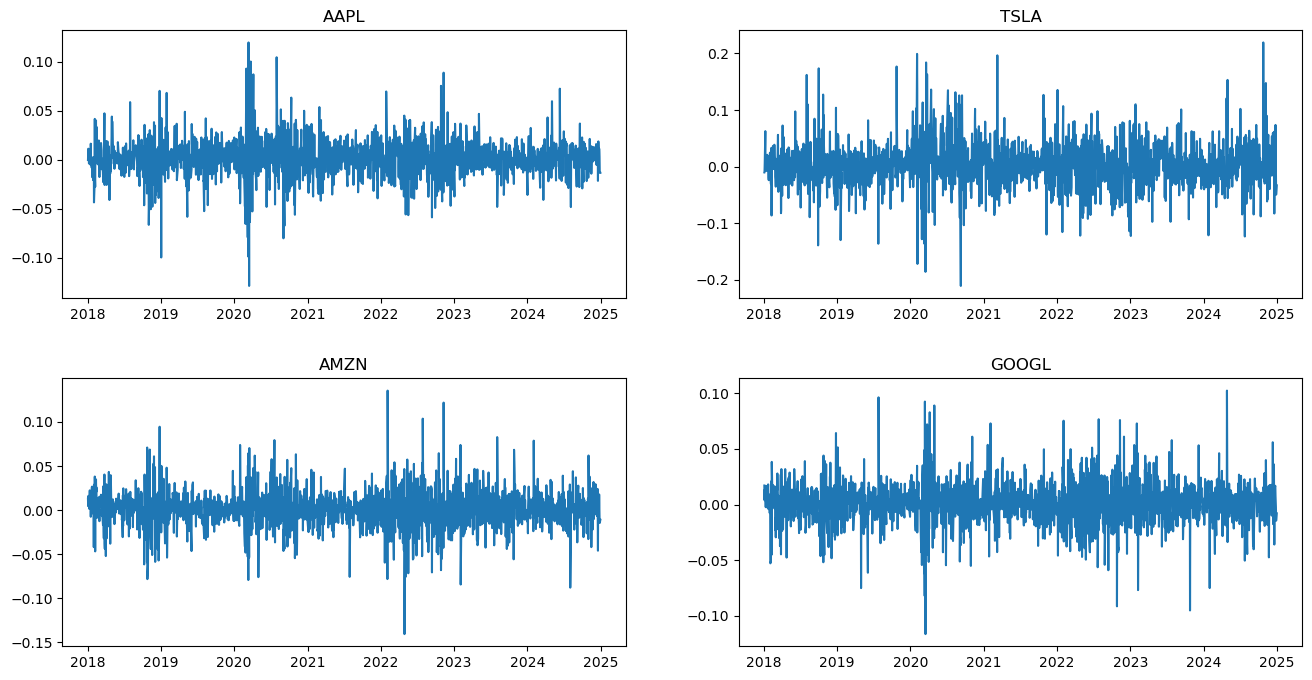

In [10]:
import yfinance as yf
import matplotlib.pyplot as plt

stocks = ['AAPL', 'TSLA', 'AMZN', 'GOOGL']

data = yf.download(stocks, start='2018-01-01', end='2024-12-31')

close_data = data['Close']

returns = close_data.pct_change().dropna()

fig, axs = plt.subplots(2, 2, figsize=(16,8),
                        gridspec_kw={'hspace':0.3,'wspace':0.2})

axs[0,0].plot(returns['AAPL'])
axs[0,0].set_title('AAPL')

axs[0,1].plot(returns['TSLA'])
axs[0,1].set_title('TSLA')

axs[1,0].plot(returns['AMZN'])
axs[1,0].set_title('AMZN')

axs[1,1].plot(returns['GOOGL'])
axs[1,1].set_title('GOOGL')

plt.show()

## SINGLE STOCK ANALYSIS(APPLE)

[*********************100%***********************]  1 of 1 completed


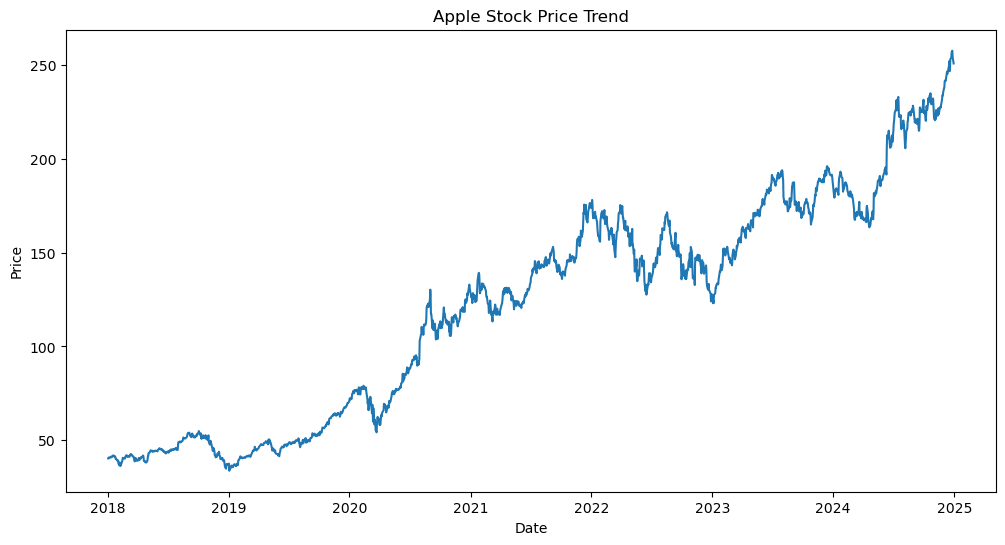

In [11]:
apple = yf.download("AAPL",start="2018-01-01",end="2024-12-31")

plt.figure(figsize=(12,6))

plt.plot(apple['Close'])

plt.title("Apple Stock Price Trend")

plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

## TECHNICAL INDICATORS

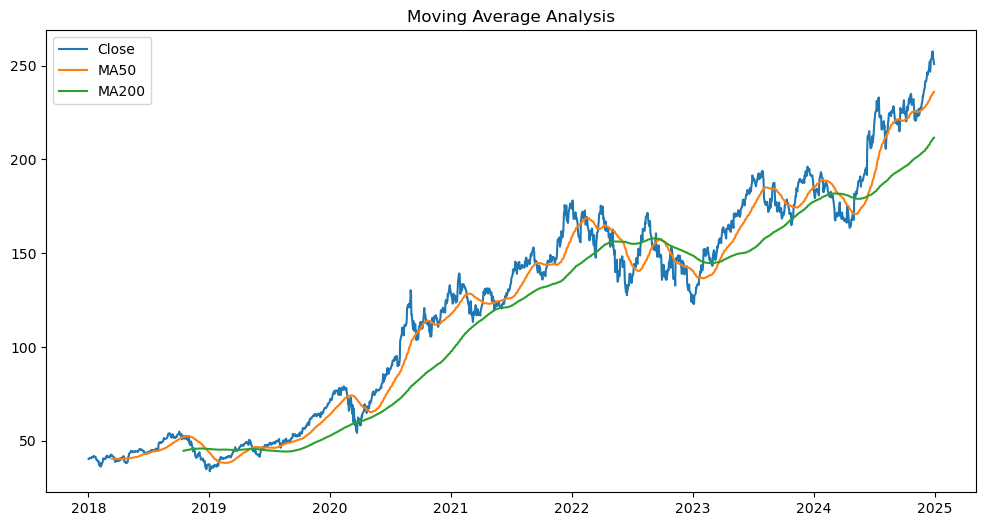

In [12]:
apple['MA50'] = apple['Close'].rolling(50).mean()
apple['MA200'] = apple['Close'].rolling(200).mean()

plt.figure(figsize=(12,6))

plt.plot(apple['Close'])
plt.plot(apple['MA50'])
plt.plot(apple['MA200'])

plt.legend(['Close','MA50','MA200'])

plt.title("Moving Average Analysis")

plt.show()

## DATA PREPROCESSING

In [13]:
dataset = apple['Close'].values

dataset = dataset.reshape(-1,1)

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(dataset)

## RANDOM FOREST MODEL

#### Prepare Data

In [14]:
X = np.arange(len(dataset)).reshape(-1,1)
y = dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

### Train Random Forest Model

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)

rf.fit(X_train, y_train.ravel())

RandomForestRegressor()

### Random Forest Prediction

In [16]:
rf_predictions = rf.predict(X_test)
print("First 10  Predicted Prices:")
print(rf_predictions[:10])

First 10  Predicted Prices:
[179.09233078 179.09233078 179.09233078 179.09233078 179.09233078
 179.09233078 179.09233078 179.09233078 179.09233078 179.09233078]


### Model Evaluation

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
mae = mean_absolute_error(y_test, rf_predictions)
r2 = r2_score(y_test, rf_predictions)

print("Random Forest Model Evaluation")
print("RMSE:", rmse)
print("MAE:", mae)
print("R2 Score:", r2)

Random Forest Model Evaluation
RMSE: 31.264162055779725
MAE: 23.272433388449926
R2 Score: -0.596045519657971


### Prediction Visualization

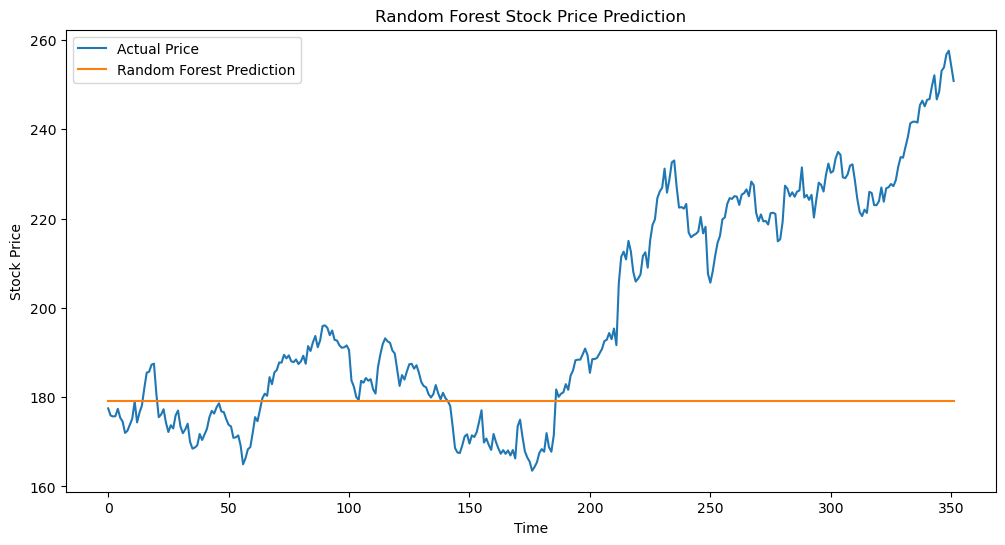

In [18]:
plt.figure(figsize=(12,6))

plt.plot(y_test, label="Actual Price")
plt.plot(rf_predictions, label="Random Forest Prediction")

plt.legend()

plt.title("Random Forest Stock Price Prediction")

plt.xlabel("Time")
plt.ylabel("Stock Price")

plt.show()

## LONG SHORT-TERM MEMORY(LSTM)

### Prepare Data for LSTM

In [19]:
train_size = int(len(scaled_data)*0.8)

train_data = scaled_data[:train_size]

x_train=[]
y_train=[]

for i in range(60,len(train_data)):
    x_train.append(train_data[i-60:i,0])
    y_train.append(train_data[i,0])

x_train,y_train = np.array(x_train),np.array(y_train)

x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))

### LSTM Model

In [20]:
model = Sequential()

model.add(LSTM(50,return_sequences=True,input_shape=(x_train.shape[1],1)))
model.add(LSTM(50))

model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam',loss='mean_squared_error')

model.fit(x_train,y_train,epochs=10,batch_size=32)



Epoch 1/10

43/43 [==============================] - 6s 35ms/step - loss: 0.0116
Epoch 2/10
43/43 [==============================] - 2s 37ms/step - loss: 5.0347e-04
Epoch 3/10
43/43 [==============================] - 2s 39ms/step - loss: 4.4570e-04
Epoch 4/10
43/43 [==============================] - 2s 42ms/step - loss: 4.4990e-04
Epoch 5/10
43/43 [==============================] - 2s 39ms/step - loss: 4.2540e-04
Epoch 6/10
43/43 [==============================] - 2s 39ms/step - loss: 4.3373e-04
Epoch 7/10
43/43 [==============================] - 2s 39ms/step - loss: 4.3796e-04
Epoch 8/10
43/43 [==============================] - 2s 40ms/step - loss: 4.1010e-04
Epoch 9/10
43/43 [==============================] - 2s 38ms/step - loss: 3.8338e-04
Epoch 10/10
43/43 [==============================] - 2s 38ms/step - loss: 3.7453e-04


### LSTM Prediction

In [21]:
test_data = scaled_data[train_size-60:]

x_test=[]

for i in range(60,len(test_data)):
    x_test.append(test_data[i-60:i,0])

x_test=np.array(x_test)

x_test=np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

predictions=model.predict(x_test)

predictions=scaler.inverse_transform(predictions)

print("First 10 Predicted Prices:")
print(predictions[:10])

11/11 [==============================] - 1s 15ms/step
First 10 Predicted Prices:
[[186.01352]
 [184.45453]
 [182.73917]
 [181.0155 ]
 [179.39674]
 [178.04416]
 [176.83372]
 [175.74402]
 [174.65343]
 [173.65982]]


### Model Evaluation

In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("LSTM RMSE:", rmse)
print("LSTM MAE:", mae)

LSTM RMSE: 8.163281474399081
LSTM MAE: 6.477316379547119


### Prediction Visualization

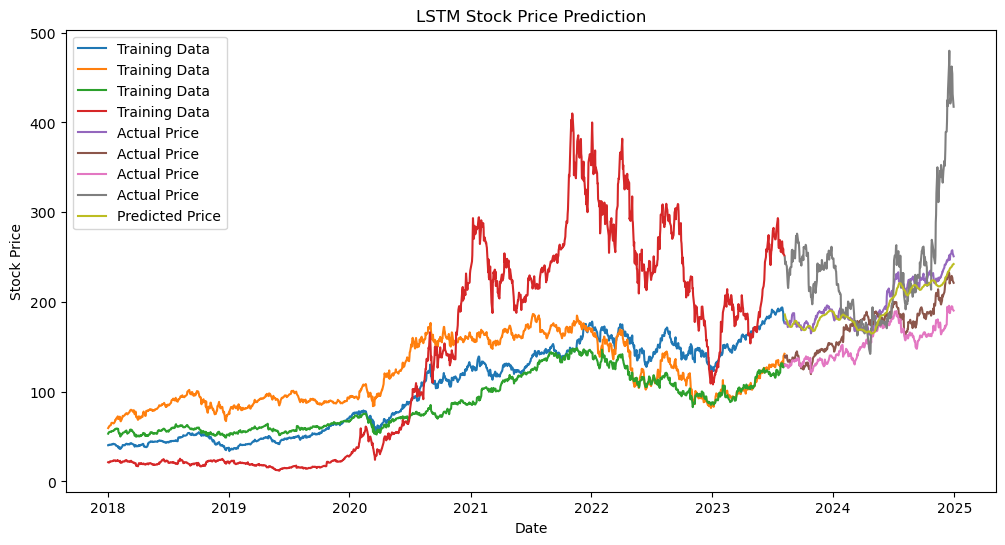

In [23]:
# Split data
train = data[:train_size]
valid = data[train_size:].copy()

# Add predictions
valid['Predictions'] = predictions

# Plot results
plt.figure(figsize=(12,6))

plt.plot(train['Close'], label="Training Data")
plt.plot(valid['Close'], label="Actual Price")
plt.plot(valid['Predictions'], label="Predicted Price")

plt.title("LSTM Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()
plt.show()

## FUTURE STOCK PRICE PREDICTION (UNTIL 2030)

In [25]:
# Predict until 2030
future_days = 2200

last_60_days = scaled_data[-60:]

future_predictions = []

current_input = last_60_days.reshape(1,60,1)

for i in range(future_days):

    pred_price = model.predict(current_input, verbose=0)

    future_predictions.append(pred_price[0][0])

    pred_price_reshaped = pred_price.reshape(1,1,1)

    current_input = np.concatenate((current_input[:,1:,:], pred_price_reshaped), axis=1)

future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))


# Create future dates
from datetime import timedelta

last_date = apple.index[-1]

future_dates = [last_date + timedelta(days=i) for i in range(1, future_days + 1)]


# Create dataframe
future_df = pd.DataFrame({
    "Date": future_dates,
    "Predicted Price": future_predictions.flatten()
})

future_df

,Date,Predicted Price
0,2024-12-31,242.688446
1,2025-01-01,242.435822
2,2025-01-02,241.720520
3,2025-01-03,240.703186
4,2025-01-04,239.493042
...,...,...
2195,2031-01-04,93.605988
2196,2031-01-05,93.603455
2197,2031-01-06,93.600914
2198,2031-01-07,93.598381


### Visualization of Future Prediction

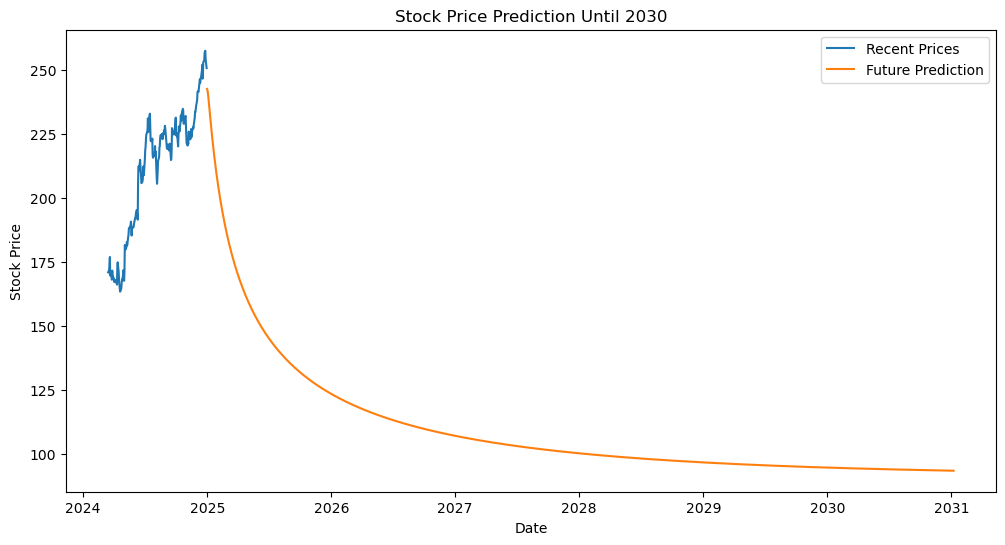

In [26]:
from datetime import timedelta

# Get last date of dataset
last_date = apple.index[-1]

# Create future dates equal to predictions
future_dates = [last_date + timedelta(days=i) for i in range(1, len(future_predictions)+1)]

# Plot graph
plt.figure(figsize=(12,6))

plt.plot(apple['Close'][-200:], label="Recent Prices")
plt.plot(future_dates, future_predictions.flatten(), label="Future Prediction")

plt.title("Stock Price Prediction Until 2030")
plt.xlabel("Date")
plt.ylabel("Stock Price")

plt.legend()
plt.show()

## CONCLUSION

This project analyzed the stock price behavior of major companies using historical data and applied machine learning techniques for prediction. Through data visualization, we identified trends, volatility patterns, and return characteristics of stocks like Apple, Tesla, Amazon, and Alphabet.

The LSTM model was used to forecast future stock prices, demonstrating its ability to capture time-series patterns effectively. The evaluation metrics (RMSE and MAE) indicate that the model provides reasonably accurate predictions, though it is not perfectly precise due to the inherently uncertain nature of stock markets.

The future prediction up to 2030 gives a projected trend rather than exact values, helping in understanding possible long-term movement. However, stock prices are influenced by many external factors such as economic conditions, company performance, and global events, which are not fully captured in the model.

Overall, this project shows that data science and machine learning can be powerful tools for stock analysis and forecasting, but predictions should be used with caution and combined with fundamental and real-world analysis for better decision-making.